In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cma_utils

In [ ]:
N_symbols = 1000000

E_in = cma_utils.gen_I_Q_16_qam(N_symbols)

# check parameters with deepa ma'am
num_taps = 151

freq_offset = 2e3
fs = 2e9

E_after_pmd = cma_utils.apply_pmd( 
E_in=E_in, 
# DGD_ps_per_sqrt_km=31.6, # typical mean DGD 
DGD_ps_per_sqrt_km=19.764,
L_m=10000, # fiber length
N_sections=20, # number of fiber sections 
Rs=32e9, # 32 gbaud
SpS=4 # samples per symbol 
)



tau_Ts 0.48540069734050556


In [3]:
output_EVM_MMA = []
output_EVM_CMA = []
convergence_symbols_MMA = []
convergence_symbols_CMA = []
SNR_arr = []
for SNR in range(0,45,5):
    SNR_arr.append(SNR)

    E_noisy = cma_utils.apply_awgn(E_after_pmd, SNR)
    E_corrected_CMA,info_dict_cma = cma_utils.cma_python(E_noisy, num_taps=num_taps, mu_CMA=1e-4)
    E_corrected_MMA,info_dict_mma = cma_utils.mma_python(E_noisy, num_taps=num_taps, mu_CMA=1e-4)

    output_EVM_MMA.append(cma_utils.cluster_and_get_avg_snr(E_corrected_MMA)[0])
    output_EVM_CMA.append(cma_utils.cluster_and_get_avg_snr(E_corrected_CMA)[0])

    cma_error = np.array(info_dict_cma['cma_error'])
    mma_error = np.array(info_dict_mma['cma_error'])

    smoothed_log_cma_error = cma_utils.plot_conv(cma_error)
    smoothed_log_mma_error = cma_utils.plot_conv(mma_error)

    convergence_symbol_cma = cma_utils.find_convergence_backward(smoothed_log_cma_error)
    convergence_symbol_mma = cma_utils.find_convergence_backward(smoothed_log_mma_error)

    convergence_symbols_CMA.append(convergence_symbol_cma)
    convergence_symbols_MMA.append(convergence_symbol_mma)

signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993
signal power is 1.0000295999999993


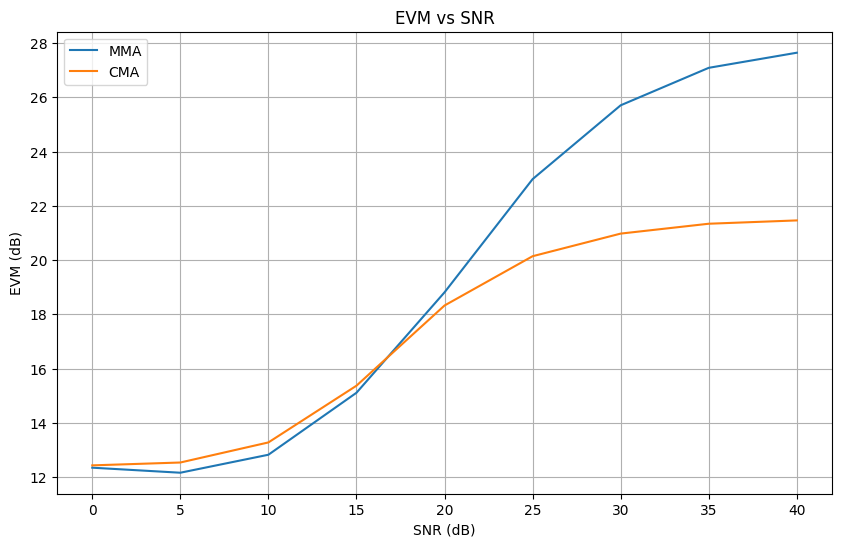

In [4]:
# Plotting EVM vs SNR
plt.figure(figsize=(10,6))
plt.plot(SNR_arr, output_EVM_MMA, label="MMA")
plt.plot(SNR_arr, output_EVM_CMA, label="CMA")
plt.xlabel("SNR (dB)")
plt.ylabel("EVM (dB)")
plt.title("EVM vs SNR")
plt.legend()
plt.grid(True)

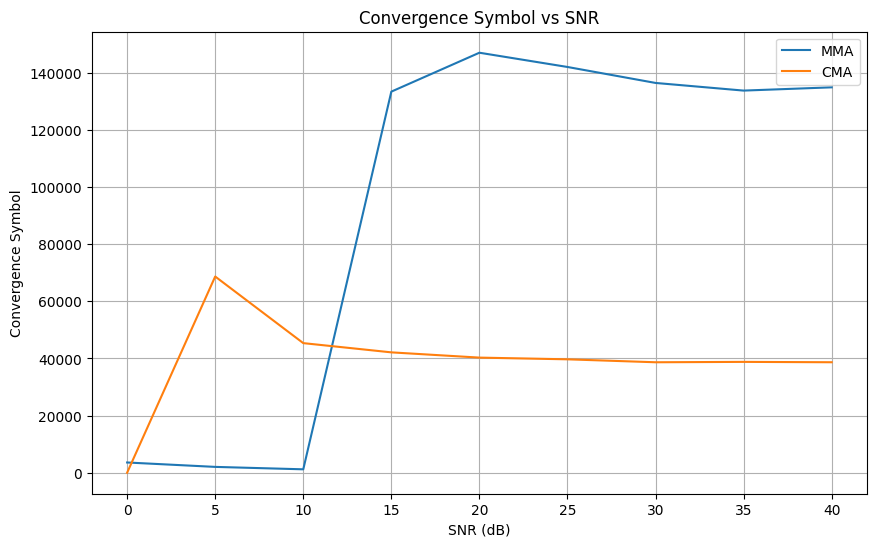

In [5]:
#Plotting convergence symbols vs SNR
plt.figure(figsize=(10,6))
plt.plot(SNR_arr, convergence_symbols_MMA, label="MMA")
plt.plot(SNR_arr, convergence_symbols_CMA, label="CMA")
plt.xlabel("SNR (dB)")
plt.ylabel("Convergence Symbol")
plt.title("Convergence Symbol vs SNR")
plt.legend()
plt.grid(True)

signal power is 0.999864800000001


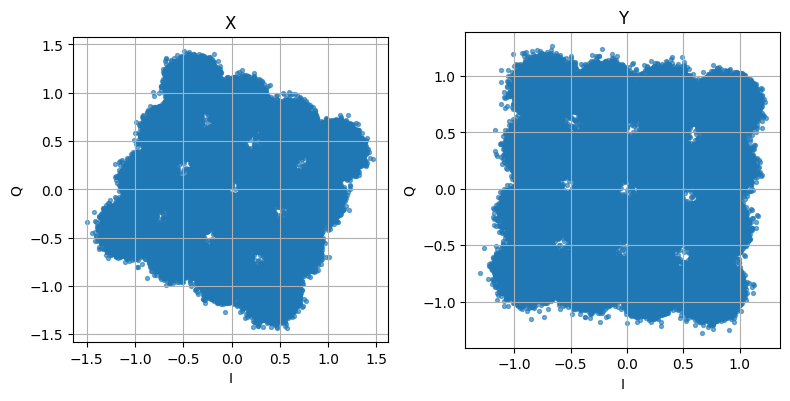

In [16]:
E_noisy = cma_utils.apply_awgn(E_after_pmd, 20)
E_after_cma, _ = cma_utils.cma_python(E_noisy, num_taps=num_taps, mu_CMA=1e-4)
cma_utils.plot_constellation(E_after_cma)